# Solution: Challenge Week 10

## Libraries and settings

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Show current working directory
print(os.getcwd())

/workspace/Week_10/challenge


## Creating the ImageAnalyzer class

In [2]:
class ImageAnalyzer:
    """
    A class for loading and analyzing images.

    Attributes
    ----------
    path : str
        File path to the image.
    img  : np.ndarray
        The loaded image as a NumPy array (height x width x 3).
    """

    def __init__(self, path):
        """
        Load an image from the given file path.

        Parameters
        ----------
        path : str
            Path to an image file (e.g. .jpg, .png).
        """
        self.path = path
        self.img  = mpimg.imread(path)
        print(f'Image loaded: {os.path.basename(path)}')
        print(f'  Shape (rows x cols x channels): {self.img.shape}')
        print(f'  Data type                      : {self.img.dtype}')

    # ------------------------------------------------------------------
    # 1. Plot the image
    # ------------------------------------------------------------------
    def plot(self, title=None):
        """Display the image in colour."""
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.imshow(self.img)
        ax.axis('off')
        ax.set_title(title or os.path.basename(self.path), fontsize=12)
        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------------
    # 2. Get image size
    # ------------------------------------------------------------------
    def get_size(self):
        """
        Return the image dimensions.

        Returns
        -------
        dict with keys 'rows', 'cols', 'channels', 'total_pixels'
        """
        rows, cols = self.img.shape[:2]
        channels   = self.img.shape[2] if self.img.ndim == 3 else 1
        return {
            'rows'        : rows,
            'cols'        : cols,
            'channels'    : channels,
            'total_pixels': rows * cols,
        }

    # ------------------------------------------------------------------
    # 3. Get values of single pixels
    # ------------------------------------------------------------------
    def get_pixel(self, row, col):
        """
        Return the RGB values of a single pixel.

        Parameters
        ----------
        row : int
            Row index (0-based).
        col : int
            Column index (0-based).

        Returns
        -------
        dict with keys 'R', 'G', 'B' (values 0–255)
        """
        pixel = self.img[row, col]
        # Convert to uint8 if the image was loaded as float (0.0–1.0)
        if self.img.dtype != np.uint8:
            pixel = (pixel * 255).astype(np.uint8)
        return {'R': int(pixel[0]), 'G': int(pixel[1]), 'B': int(pixel[2])}

    # ------------------------------------------------------------------
    # 4. Plot gray-scale version
    # ------------------------------------------------------------------
    def plot_grayscale(self):
        """Display a gray-scale version of the image."""
        # Weighted luminosity conversion  (ITU-R BT.601)
        img_float = self.img.astype(np.float32)
        if img_float.max() > 1.0:
            img_float /= 255.0
        gray = (
            0.299 * img_float[:, :, 0] +
            0.587 * img_float[:, :, 1] +
            0.114 * img_float[:, :, 2]
        )
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.imshow(gray, cmap='gray')
        ax.axis('off')
        ax.set_title(f'{os.path.basename(self.path)} – Gray-scale', fontsize=12)
        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------------
    # 5. Plot overlapping RGB histograms
    # ------------------------------------------------------------------
    def plot_rgb_histogram(self):
        """Plot overlapping histograms for the R, G and B colour channels."""
        # Ensure uint8 values (0–255)
        img_uint = self.img
        if img_uint.dtype != np.uint8:
            img_uint = (img_uint * 255).astype(np.uint8)

        fig, ax = plt.subplots(figsize=(8, 4))
        colors  = [('R', 'red'), ('G', 'green'), ('B', 'blue')]
        for i, (label, color) in enumerate(colors):
            ax.hist(
                img_uint[:, :, i].ravel(),
                bins=256,
                range=(0, 255),
                color=color,
                alpha=0.4,
                label=label,
            )
        ax.set_xlim(0, 255)
        ax.set_title(f'{os.path.basename(self.path)} – RGB Histogram', fontsize=12)
        ax.set_xlabel('Pixel intensity')
        ax.set_ylabel('Frequency')
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------------
    # 6. Write RGB values to a pandas DataFrame
    # ------------------------------------------------------------------
    def to_dataframe(self):
        """
        Flatten the image and return a DataFrame with one row per pixel.

        Returns
        -------
        pd.DataFrame with columns: row, col, R, G, B
        """
        img_uint = self.img
        if img_uint.dtype != np.uint8:
            img_uint = (img_uint * 255).astype(np.uint8)

        rows, cols = img_uint.shape[:2]
        row_idx, col_idx = np.meshgrid(
            np.arange(rows), np.arange(cols), indexing='ij'
        )

        df = pd.DataFrame({
            'row': row_idx.ravel(),
            'col': col_idx.ravel(),
            'R'  : img_uint[:, :, 0].ravel(),
            'G'  : img_uint[:, :, 1].ravel(),
            'B'  : img_uint[:, :, 2].ravel(),
        })
        return df

## Using the ImageAnalyzer class

### Load the image

In [3]:
# Path to the sample image (placed in the same folder as this notebook)
img_path = './amsterdam-canal-house.jpeg'

analyzer = ImageAnalyzer(img_path)

Image loaded: amsterdam-canal-house.jpeg
  Shape (rows x cols x channels): (381, 600, 3)
  Data type                      : uint8


### Plot the image

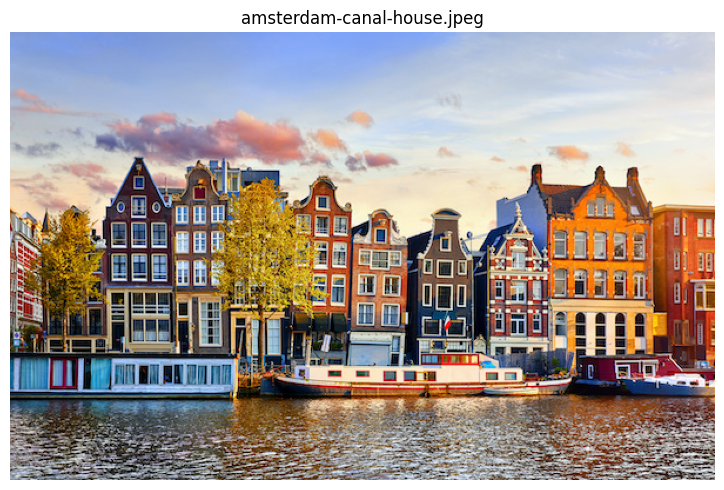

In [4]:
analyzer.plot()

### Get the image size

In [5]:
size = analyzer.get_size()
print(f'Rows         : {size["rows"]}')
print(f'Cols         : {size["cols"]}')
print(f'Channels     : {size["channels"]}')
print(f'Total pixels : {size["total_pixels"]:,}')

Rows         : 381
Cols         : 600
Channels     : 3
Total pixels : 228,600


### Get values of single pixels

In [6]:
# Sample pixel at position (0, 0) – top-left corner
px = analyzer.get_pixel(0, 0)
print(f'Pixel (0, 0)  -> R={px["R"]}, G={px["G"]}, B={px["B"]}')

# Sample pixel near the centre of the image
rows = analyzer.img.shape[0]
cols = analyzer.img.shape[1]
px_centre = analyzer.get_pixel(rows // 2, cols // 2)
print(f'Pixel (centre) -> R={px_centre["R"]}, G={px_centre["G"]}, B={px_centre["B"]}')

Pixel (0, 0)  -> R=129, G=155, B=216
Pixel (centre) -> R=164, G=133, B=105


### Plot gray-scale version

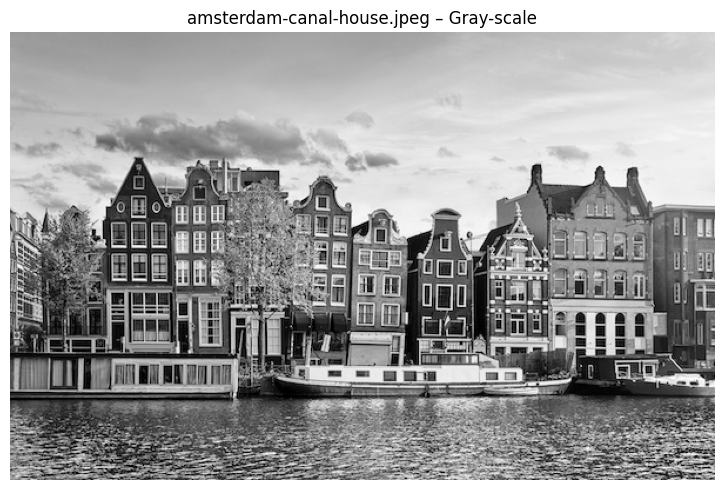

In [7]:
analyzer.plot_grayscale()

### Plot overlapping RGB histograms

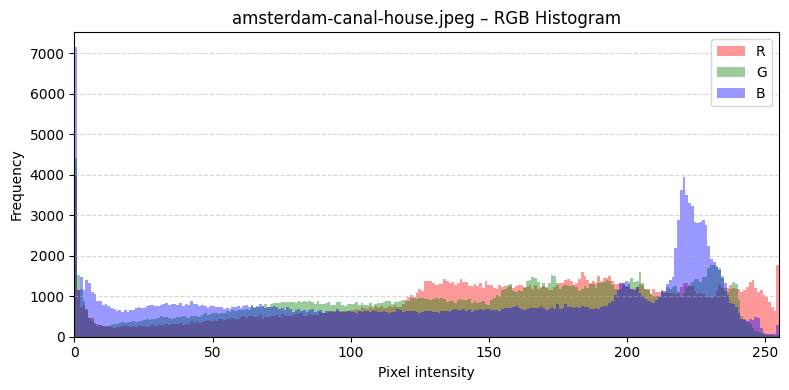

In [8]:
analyzer.plot_rgb_histogram()

### Write RGB values to a pandas DataFrame

In [9]:
df_pixels = analyzer.to_dataframe()

print(f'Shape of DataFrame : {df_pixels.shape}')
print(f'\nDescriptive statistics for RGB channels:')
print(df_pixels[['R', 'G', 'B']].describe().round(1))
df_pixels.head(10)

Shape of DataFrame : (228600, 5)

Descriptive statistics for RGB channels:
              R         G         B
count  228600.0  228600.0  228600.0
mean      153.4     142.0     136.7
std        66.2      68.3      80.1
min         0.0       0.0       0.0
25%       114.0      89.0      63.0
50%       162.0     155.0     150.0
75%       205.0     199.0     217.0
max       255.0     255.0     255.0


,row,col,R,G,B
0,0,0,129,155,216
1,0,1,128,154,215
2,0,2,128,153,217
3,0,3,128,153,217
4,0,4,127,155,218
5,0,5,127,155,218
6,0,6,127,155,218
7,0,7,127,155,218
8,0,8,127,155,218
9,0,9,127,155,218


## Analyze a second image

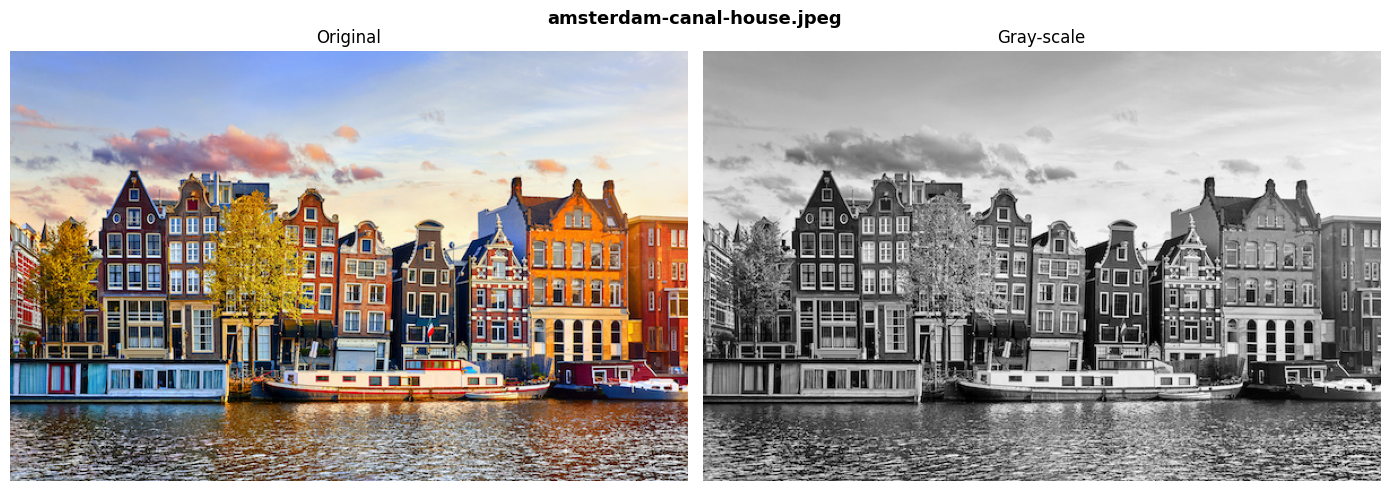

In [10]:
# --------------------------------------------------------------------
# To analyze another photo, change the path below to point to any
# .jpg / .png file on your machine or download one, e.g.:
#
#   import requests
#   url = 'https://live.staticflickr.com/..../photo.jpg'
#   with open('photo2.jpg', 'wb') as f:
#       f.write(requests.get(url).content)
#
# Then run:
#   analyzer2 = ImageAnalyzer('photo2.jpg')
#   analyzer2.plot()
#   analyzer2.plot_grayscale()
#   analyzer2.plot_rgb_histogram()
#   df2 = analyzer2.to_dataframe()
# --------------------------------------------------------------------

# Side-by-side comparison: colour vs. gray-scale
img_uint = analyzer.img
if img_uint.dtype != np.uint8:
    img_uint = (img_uint * 255).astype(np.uint8)

img_float = img_uint.astype(np.float32) / 255.0
gray = (
    0.299 * img_float[:, :, 0] +
    0.587 * img_float[:, :, 1] +
    0.114 * img_float[:, :, 2]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_uint)
axes[0].axis('off')
axes[0].set_title('Original', fontsize=12)

axes[1].imshow(gray, cmap='gray')
axes[1].axis('off')
axes[1].set_title('Gray-scale', fontsize=12)

plt.suptitle(os.path.basename(img_path), fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [11]:
import os
import platform
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1044-azure
Datetime: 2026-04-22 15:45:03
Python Version: 3.11.14
-----------------------------------
